In [1]:
using Revise
includet("../../scripts/single_influx.jl")
import SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Load data (takes ~3min)

In [4]:
f = jldopen("../../cluster_env/runs/single_influx/gd5_forfigures_260212_153215.jld2");
Ks, lis, rslts = make_Kli_matrix(f);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


In [5]:
f2 = jldopen("../../data/forfigures/fig1/si_li1.jld2")
li1df = f2["li1df"]
li1cdf = f2["li1cdf"];

In [6]:
rdfs = f["raw_dfs"];

# Plotting dominant states as a K vs l phase diagram

In [7]:
dominant = map(rslts) do x
    am = argmax([x.extinct, x.nonext_unstable, x.nonext_stable])
    if am == 1
        PaperColors.extinct1()
    elseif am == 2
        PaperColors.unstable1()
    else
        PaperColors.stable1()
    end
end;

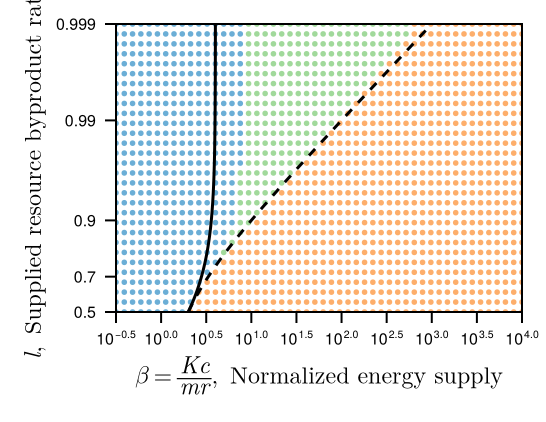

In [ ]:
plotlines = true

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.47),
    figure_padding=(12., 12., 12., 12.),
)
ax = Axis(fig[1,1];
    # aspect=AxisAspect(1.2),
    xscale=log10,
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    xgridvisible=false,
    ygridvisible=false,
)

leakxs = LeakageScale.ltox.(lis)
# heatmap!(ax, Ks, leakxs, dominant)
scatter!(ax, [(x, y) for x in Ks for y in leakxs];
    # marker='.',
    markersize=4,
    color=dominant'[:]
)

if plotlines
    p = 1.

    thr_leakxs = range(extrema(leakxs)..., 1000)
    thr_ls = LeakageScale.l.(thr_leakxs)

    extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)
    instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p)

    lines!(ax, extline_Ks, thr_leakxs;
        color=:black,
    )
    lines!(ax, instabline_Ks, thr_leakxs;
        color=:black,
        linestyle=:dash,
    )

    xlims!(ax, extrema(Ks))
    ylims!(ax, extrema(leakxs))
end

eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1-e)) for e in eps_ticks])
# ax.ylabel = L"l,\enspace\text{Supplied resource leakage}"
ax.ylabel = L"l,\enspace\text{Supplied resource byproduct ratio}"
# ax.xlabel = L"K,\enspace\text{Amount of energy being supplied}"
ax.xlabel = L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}"

# ax.ylabelpadding = -3.

Makie.save("../../figures2/fig2/outcome_pd_si.pdf", fig)

fig

# Instability region changing with p

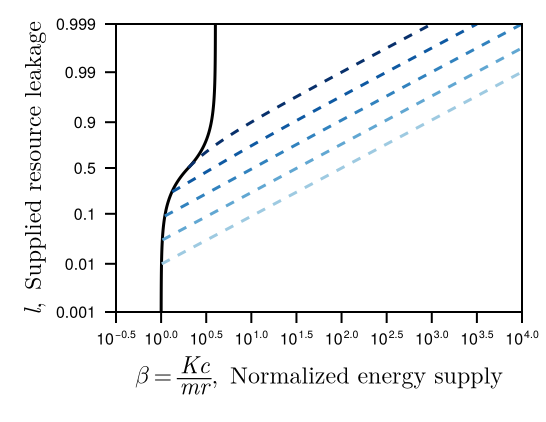

In [ ]:
lticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    # size=(double_col_width * 0.4, (double_col_width / golden_ratio) * 0.47),
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.47),
    # size=(double_col_width * 0.55, (double_col_width / golden_ratio) * 0.6),
    figure_padding=(12., 12., 12., 12.),
)
ax = Axis(fig[1:2,1],
    # aspect=AxisAspect(1.2),
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    xscale=log10,
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"l,\enspace\text{Supplied resource leakage}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    xgridvisible=false,
    ygridvisible=false,
)

thr_leakxs = range(LeakageScale.ltox(0.001), LeakageScale.ltox(0.999), 1000)
thr_ls = LeakageScale.l.(thr_leakxs)

extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)

lines!(ax, extline_Ks, thr_leakxs;
    color=:black,
)

logps = range(0., -2, 5)
ps = 10 .^ logps
ps_cmap = cgrad(ColorSchemes.Blues[4:end])

lalal = extrema(logps)
logps_delta = lalal[2] - lalal[1]
logps_min = lalal[1]

for logp in logps
    p_ = 10 ^ logp
    instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p_)
    lines!(ax, instabline_Ks, thr_leakxs;
        color=get(ps_cmap, (logp - logps_min) / logps_delta),
        linestyle=:dash,
        label=rich("p=10", superscript(@sprintf "%.3g" logp)),
        # label=latexstring(@sprintf "D_R = 10^{%.3g}D_I" logp)
    )
end

xlims!(ax, extrema(Ks))
ylims!(ax, extrema(thr_leakxs))

#= Colorbar(fig[1:2,2];
    limits=extrema(ps),
    colormap=ps_cmap,
    scale=log10,
    size=4,
    ticklabelsize=6fontsize_pt,
    labelsize=6fontsize_ltex_pt,
    label=L"p=\frac{D_R}{D_I}",
    ticksize=2,
    ticklabelpad=0,
) =#
# Label(fig[1,2], L"p=\frac{D_R}{D_I}";
#     rotation=pi/2,
# )

colgap!(fig.layout, 4.)
# rowsize!(fig.layout, 2, Relative(0.8))

Makie.save("../../figures2/fig2/lines_changing_p.pdf", fig)

# display(GLMakie.Screen(), fig)

fig

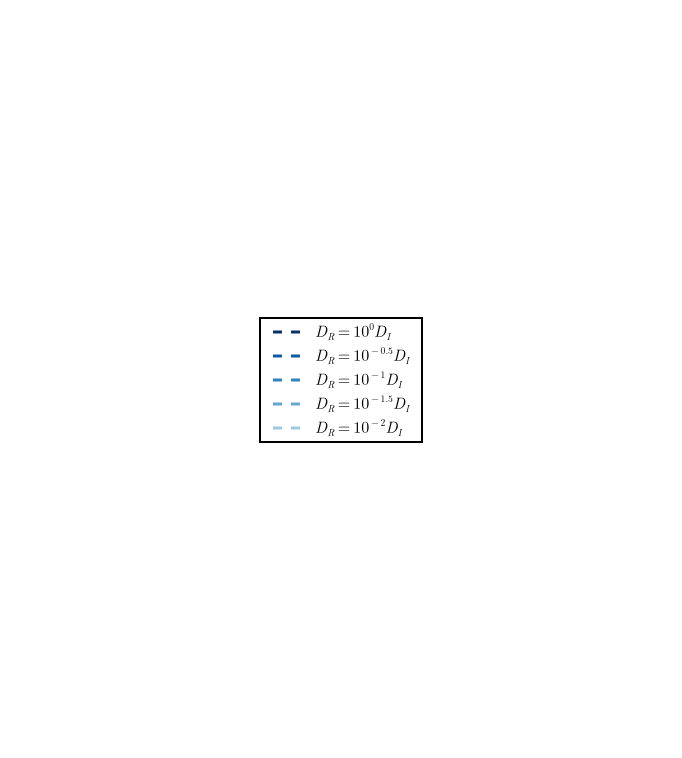

In [ ]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.9),
)
Legend(fig[1,1], ax;
    labelsize=6fontsize_pt,
    rowgap=2.,
    patchsize=(16, 10),
    padding=(6., 6., 2., 2.)
)
Makie.save("../../figures2/fig2/ps_legend.pdf", fig)
fig

# Proportions plot

In [20]:
li1xx = [(; extinct=r.extinct, nonext_stable=r.nonext_stable, nonext_unstable=r.nonext_unstable, num_runs=r.num_runs) for r in eachrow(li1cdf)];

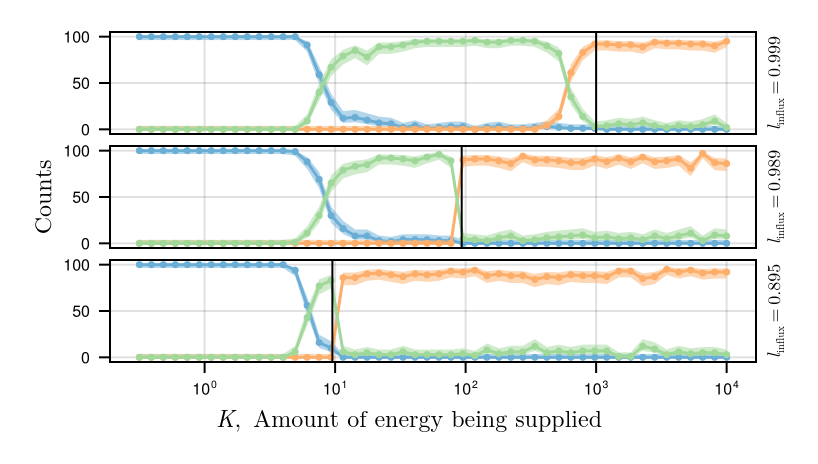

In [28]:
faflis = []
fafcounts = Any[]

for i in [length(lis), length(lis)-10, length(lis)-20]
    push!(faflis, lis[i])
    push!(fafcounts, rslts[:,i])
end

fig = Figure(;
   size=(double_col_width * 0.60, 0.55 * double_col_width / golden_ratio),
)

axs = []
for i in 1:length(faflis)
    li = faflis[i]
    cs = fafcounts[i]

    ax = Axis(fig[i,1];
        xscale=log10,
        xticklabelsize=6fontsize_pt,
        yticklabelsize=6fontsize_pt,
    )
    ylims!(ax, -5, 105)
    push!(axs, ax)
    Label(fig[i,2], latexstring(@sprintf "l_\\text{influx}=%.3f" li);
        rotation=pi/2,
        tellheight=false,
        fontsize=6fontsize_ltex_pt,
    )
    
    num_runs = [x.num_runs for x in cs]
    plot_binom_sample!(ax, Ks, [x.extinct for x in cs], num_runs;
        color=PaperColors.extinct1(),
        sl_kwargs=(; markersize=5.),
    )
    plot_binom_sample!(ax, Ks, [x.nonext_stable for x in cs], num_runs;
        color=PaperColors.stable1(),
        sl_kwargs=(; markersize=5.),
    )
    plot_binom_sample!(ax, Ks, [x.nonext_unstable for x in cs], num_runs;
        color=PaperColors.unstable1(),
        sl_kwargs=(; markersize=5.),
    )
        
    thrbdr = 1 / (1 - li)
    if isfinite(thrbdr)
        vlines!(ax, thrbdr;
            color=:black,
            linewidth=1.,
        )
    end
end

for i in 1:(length(axs)-1)
    linkxaxes!(axs[end], axs[i])
    hidexdecorations!(axs[i]; grid=false)
end

Label(fig[:,0], L"\text{Counts}";
    rotation=pi/2,
    tellheight=false,
    fontsize=8fontsize_ltex_pt,
)

Label(fig[end+1,:], L"K,\enspace\text{Amount of energy being supplied}";
    tellwidth=false,
    fontsize=8fontsize_ltex_pt,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 5.)

Makie.save("../../figures2/fig1/outcomes.pdf", fig)

fig

# Plot a sample SI dispersion relation

In [63]:
cK = Ks[22]
@show cK
xx = @subset li1df :K .== cK :lscode .== 2
@show nrow(xx)
# yy = rand(eachrow(xx));
yy = xx[1,:];

cK = 26.826957952797258
nrow(xx) = 95


In [80]:
ks = 10 .^ range(-5, 2, 2000)
lsfunc = linstab_make_k_func(yy.params, yy.steadystates)
lambdas = lsfunc.(ks);
# faa = plot_linstab_lambdas(ks, lambdas)
# display(GLMakie.Screen(), faa.figure)
# faa.figure

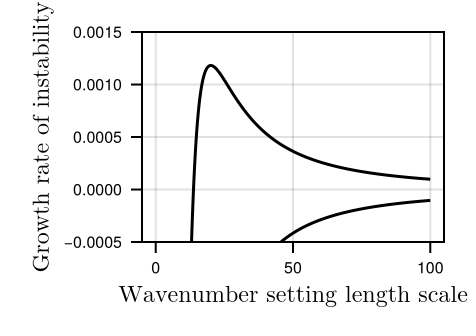

In [75]:
fig = Figure(;
    size=(double_col_width * 0.35, 0.4 * double_col_width / golden_ratio),
)
ax = Axis(fig[1,1];
    xlabel=L"\text{Wavenumber setting length scale}",
    ylabel=L"\text{Growth rate of instability}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    # ylabel=L"\lambda,\enspace\text{growth rate}",
    # xlabel=L"k,\enspace\text{wavenumber}",
)

num_lambdas = length(lambdas[1])

for li in 1:num_lambdas
    ls = getindex.(lambdas, li)

    lines!(ax, ks, real(ls);
        color=:black,
    )
end

ylims!(ax, -0.0005, 0.0015)

Makie.save("../../figures/fig1/disprel_si_sample.pdf", fig)

fig